In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

In [3]:
# Data
X = np.array([1, 3])
Y = np.array([3, 6])

In [4]:
# Core Mathematical Functions

def predict(x, m, b):
    """Compute predictions for given parameters."""
    return m * x + b


def compute_mse(y_true, y_pred):
    """Compute Mean Squared Error."""
    return np.mean((y_true - y_pred) ** 2)


def compute_gradients(x, y, m, b):
    """
    Compute gradients of MSE with respect to m and b.
    Derived manually from:
    J(m,b) = (1/n) Σ (y - (mx+b))^2
    """
    n = len(x)
    y_pred = predict(x, m, b)

    dm = (-2 / n) * np.sum(x * (y - y_pred))
    db = (-2 / n) * np.sum(y - y_pred)

    return dm, db


def update_parameters(m, b, dm, db, alpha):
    """Update m and b using gradient descent rule."""
    m_new = m - alpha * dm
    b_new = b - alpha * db
    return m_new, b_new

In [5]:
# Gradient Descent Procedure

def gradient_descent(x, y, m_init, b_init, alpha, iterations):
    m = m_init
    b = b_init

    m_history = []
    b_history = []
    error_history = []

    for i in range(iterations):
        print(f"\nIteration {i+1}")
        print("---------------------")

        # Step 1: Prediction
        y_pred = predict(x, m, b)
        print("Predictions:", y_pred)

        # Step 2: Compute Error
        error = compute_mse(y, y_pred)
        print("MSE:", error)

        # Step 3: Compute Gradients
        dm, db = compute_gradients(x, y, m, b)
        print("Gradient dm:", dm)
        print("Gradient db:", db)

        # Step 4: Update Parameters
        m, b = update_parameters(m, b, dm, db, alpha)
        print("Updated m:", m)
        print("Updated b:", b)

        # Store history
        m_history.append(m)
        b_history.append(b)
        error_history.append(error)

    return m, b, m_history, b_history, error_history

In [8]:
# Run Gradient Descent

m_initial = -1
b_initial = 1
alpha = 0.1
iterations = 3

final_m, final_b, m_hist, b_hist, error_hist = gradient_descent(
    X, Y, m_initial, b_initial, alpha, iterations
)

print("\nFinal Parameters:")
print("m =", final_m)
print("b =", final_b)


Iteration 1
---------------------
Predictions: [ 0 -2]
MSE: 36.5
Gradient dm: -27.0
Gradient db: -11.0
Updated m: 1.7000000000000002
Updated b: 2.1

Iteration 2
---------------------
Predictions: [3.8 7.2]
MSE: 1.0400000000000016
Gradient dm: 4.400000000000004
Gradient db: 2.0000000000000013
Updated m: 1.2599999999999998
Updated b: 1.9

Iteration 3
---------------------
Predictions: [3.16 5.68]
MSE: 0.06400000000000004
Gradient dm: -0.8000000000000012
Gradient db: -0.1600000000000006
Updated m: 1.3399999999999999
Updated b: 1.916

Final Parameters:
m = 1.3399999999999999
b = 1.916


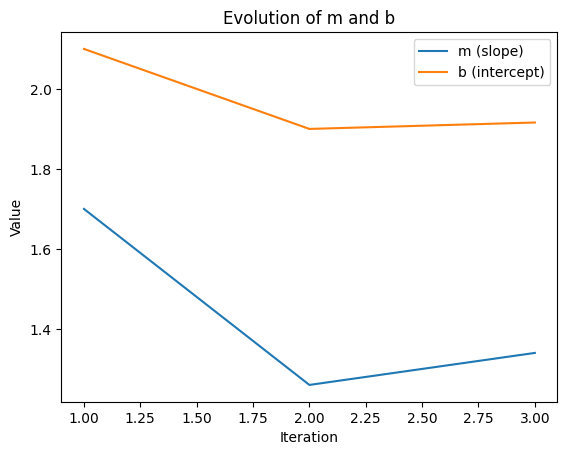

In [12]:
# Visualization 1: m and b

plt.figure()
plt.plot(range(1, iterations+1), m_hist, label="m (slope)")
plt.plot(range(1, iterations+1), b_hist, label="b (intercept)")
plt.xlabel("Iteration")
plt.ylabel("Value")
plt.title("Evolution of m and b")
plt.legend()
plt.show()

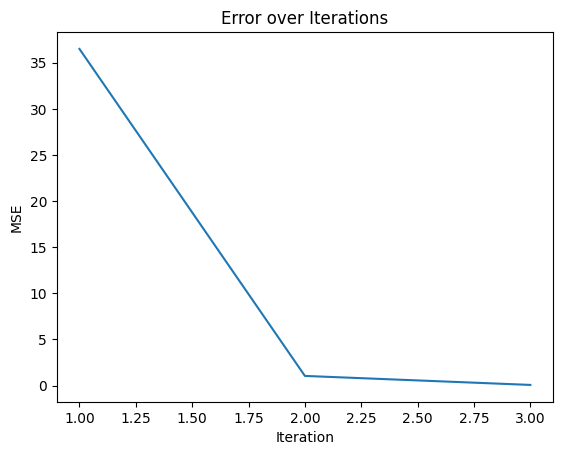

In [10]:
# Visualization 2: Error

plt.figure()
plt.plot(range(1, iterations+1), error_hist)
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Error over Iterations")
plt.show()